# Composição ou contexto?

**Urna em Camadas** · modelos explicativos e análise espacial do 1º turno presidencial de 2026

Um estado pode votar diferente porque a sua população é diferente (composição) ou porque o lugar pesa por si (contexto).
Este notebook mostra os resultados de `pipeline/10_hlm_stepup.py` e `pipeline/11_espacial.py`; o desenho foi fixado em
[`docs/plano_de_analise.md`](../docs/plano_de_analise.md) antes dos resultados.

- **Y**: logit empírico da proporção de votos do candidato nos válidos da seção (Lula, 13; Flávio Bolsonaro, 22).
- **Níveis**: seção → município → estado (e local de votação no modelo de 4 níveis).
- **Tudo descreve lugares, não pessoas** (falácia ecológica). Nada aqui é causal.

In [1]:
import json
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAIZ = Path('..')
stepup = json.loads((RAIZ / 'resultados/10_hlm_stepup.json').read_text(encoding='utf-8'))
espacial = json.loads((RAIZ / 'resultados/11_espacial.json').read_text(encoding='utf-8'))
C = {'13': stepup['candidatos']['13'], '22': stepup['candidatos']['22']}
NOME = {'13': 'Lula', '22': 'Flávio Bolsonaro'}
COR = {'13': '#e34948', '22': '#2a78d6'}          # os mesmos do site
TINTA, TINTA2, TINTA3, GRADE = '#0b0b0b', '#52514e', '#6f6d68', '#e1e0d9'
plt.rcParams.update({'font.size': 10, 'axes.edgecolor': GRADE, 'axes.labelcolor': TINTA2, 'xtick.color': TINTA2,
                     'ytick.color': TINTA2, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.color': GRADE, 'grid.linewidth': 0.8, 'axes.axisbelow': True,
                     'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb', 'savefig.facecolor': '#fcfcfb'})
pd.options.display.float_format = '{:,.3f}'.format
print(f"{stepup['n_secoes']:,} seções, {stepup['n_municipios']:,} municípios")

497,495 seções, 5,570 municípios


## 1. Sequência step-up

Variância de cada nível e quanto ela cai em relação ao modelo sem explicações. Testes de razão de verossimilhança (ML).

In [2]:
linhas = []
for n in ('13', '22'):
    for nome, m in C[n]['sequencia'].items():
        linhas.append({'candidato': NOME[n], 'modelo': nome, 'var. estado': m['uf'], 'var. município': m['mun'],
                       'var. seção': m['secao'], 'queda estado': m['queda']['uf'], 'queda município': m['queda']['mun'],
                       'queda seção': m['queda']['secao']})
pd.DataFrame(linhas).set_index(['candidato', 'modelo'])

var. estado  var. município  \
candidato        modelo                                                  
Lula             M0 nulo                         0.522           0.193   
                 M1 perfil da seção              0.443           0.174   
                 M2 + perfil do município        0.153           0.120   
                 M3 + região                     0.054           0.121   
Flávio Bolsonaro M0 nulo                         0.508           0.180   
                 M1 perfil da seção              0.412           0.168   
                 M2 + perfil do município        0.160           0.122   
                 M3 + região                     0.053           0.122   

                                           var. seção  queda estado  \
candidato        modelo                                               
Lula             M0 nulo                        0.137         0.000   
                 M1 perfil da seção             0.107         0.152   
                 M2 + perfil do município       0.107         0.706   
                 M3 + região                    0.107         0.897   
Flávio Bolsonaro M0 nulo                        0.130         0.000   
                 M1 perfil da seção             0.106         0.189   
                 M2 + perfil do município       0.106         0.685   
                 M3 + região                    0.106         0.895   

                                           queda município  queda seção  
candidato        modelo                                                  
Lula             M0 nulo                             0.000        0.000  
                 M1 perfil da seção                  0.100        0.223  
                 M2 + perfil do município            0.376        0.223  
                 M3 + região                         0.375        0.223  
Flávio Bolsonaro M0 nulo                             0.000        0.000  
                 M1 perfil da seção                  0.064        0.188  
                 M2 + perfil do município            0.321        0.188  
                 M3 + região                         0.320        0.188

In [3]:
pd.DataFrame({NOME[n]: {k: f"χ² = {v['LR']:,.0f} ({v['gl']} gl), p = {v['p']:.1e}" for k, v in C[n]['testes'].items()}
              for n in ('13', '22')})

,Lula,Flávio Bolsonaro
M0 → M1,"χ² = 124,760 (5 gl), p = 0.0e+00","χ² = 102,580 (5 gl), p = 0.0e+00"
M1 → M2,"χ² = 1,990 (6 gl), p = 0.0e+00","χ² = 1,728 (6 gl), p = 0.0e+00"
M2 → M3,"χ² = 22 (4 gl), p = 2.2e-04","χ² = 19 (4 gl), p = 6.9e-04"


## 2. O que explica a camada do estado

Valor de Shapley: a média, em todas as 128 ordens de entrada dos 7 grupos, da queda da variância do estado atribuída a
cada grupo. Painéis pequenos com a mesma escala, um por candidato.

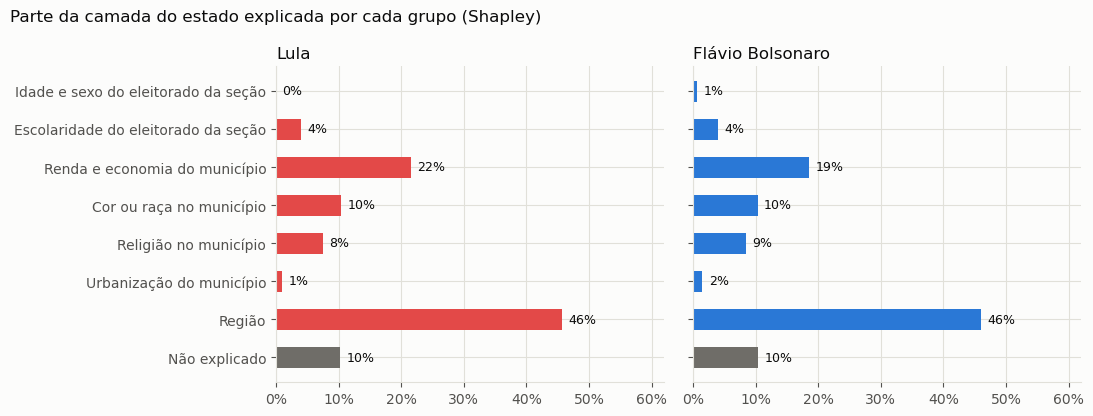

In [4]:
ROT = stepup['rotulos_blocos']
fig, eixos = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True, sharex=True)
for ax, n in zip(eixos, ('13', '22')):
    s = C[n]['shapley']['uf']['com_regiao']
    blocos = list(ROT)
    valores = [s['blocos'][b] for b in blocos] + [1 - s['total']]
    rotulos = [ROT[b] for b in blocos] + ['Não explicado']
    y = np.arange(len(valores))[::-1]
    ax.barh(y, valores, height=0.55, color=[COR[n]] * len(blocos) + [TINTA3])
    for yi, v in zip(y, valores):
        ax.text(max(v, 0) + 0.01, yi, f'{(0 if abs(v) < 0.005 else v):.0%}', va='center', color=TINTA, fontsize=9)
    ax.set_yticks(y, rotulos)
    ax.set_title(NOME[n], loc='left', color=TINTA)
    ax.set_xlim(0, 0.62)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
fig.suptitle('Parte da camada do estado explicada por cada grupo (Shapley)', x=0.01, ha='left', color=TINTA)
fig.tight_layout()

In [5]:
pd.DataFrame({f"{NOME[n]} ({'com' if r == 'com_regiao' else 'sem'} região)": {**C[n]['shapley']['uf'][r]['blocos'], 'total': C[n]['shapley']['uf'][r]['total']}
              for n in ('13', '22') for r in ('com_regiao', 'sem_regiao')}).rename(index=ROT)

,Lula (com região),Lula (sem região),Flávio Bolsonaro (com região),Flávio Bolsonaro (sem região)
Idade e sexo do eleitorado da seção,-0.004,-0.006,0.007,0.003
Escolaridade do eleitorado da seção,0.040,0.006,0.040,0.014
Renda e economia do município,0.215,0.364,0.185,0.310
Cor ou raça no município,0.104,0.165,0.103,0.170
Religião no município,0.076,0.160,0.085,0.169
Urbanização do município,0.010,0.017,0.015,0.019
Região,0.457,NaN,0.460,NaN
total,0.897,0.706,0.895,0.685


## 3. Estado a estado, antes e depois do perfil

Efeito de cada estado em pontos percentuais para uma urna típica, no modelo sem explicações (anel) e depois do perfil das
seções e dos municípios (ponto), sem o bloco de região.

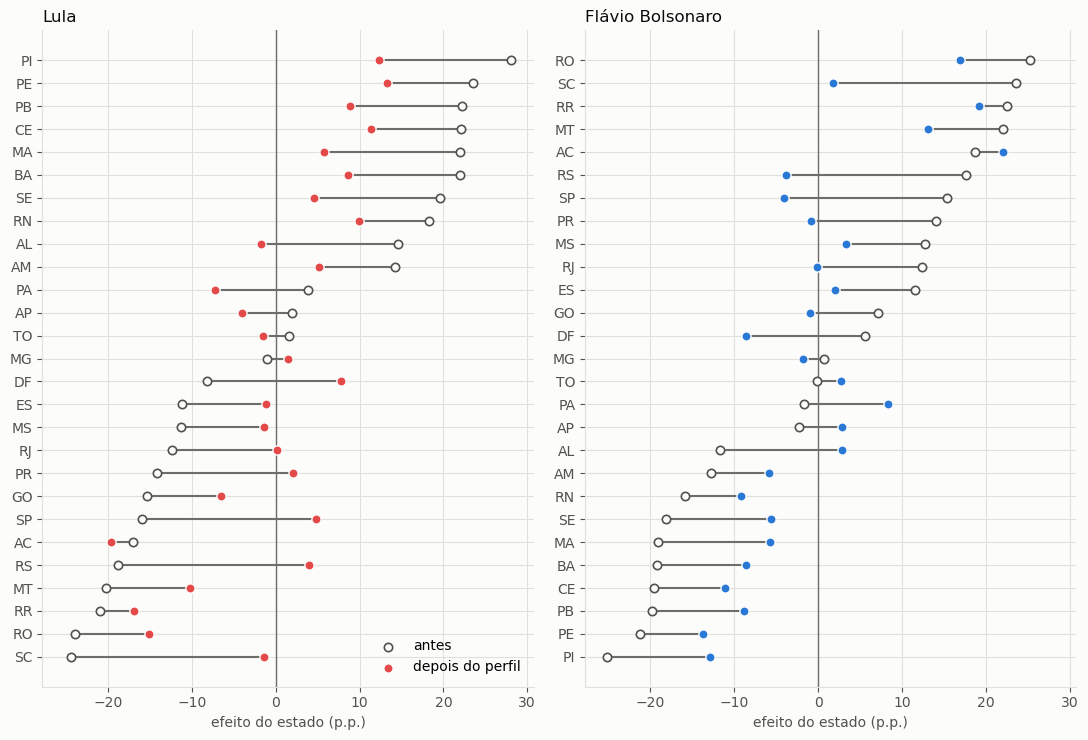

In [6]:
fig, eixos = plt.subplots(1, 2, figsize=(11, 7.5), sharex=True)
for ax, n in zip(eixos, ('13', '22')):
    e = C[n]['efeito_estado_pp']
    ufs = sorted(e['nulo'], key=lambda u: e['nulo'][u])
    y = np.arange(len(ufs))
    antes = np.array([e['nulo'][u] for u in ufs]) * 100
    depois = np.array([e['perfis'][u] for u in ufs]) * 100
    ax.hlines(y, antes, depois, color=TINTA3, lw=1.5)
    ax.scatter(antes, y, s=36, facecolor='#fcfcfb', edgecolor=TINTA2, lw=1.2, zorder=3, label='antes')
    ax.scatter(depois, y, s=44, color=COR[n], edgecolor='#fcfcfb', lw=1, zorder=4, label='depois do perfil')
    ax.axvline(0, color=TINTA3, lw=1)
    ax.set_yticks(y, ufs)
    ax.set_title(NOME[n], loc='left', color=TINTA)
    ax.set_xlabel('efeito do estado (p.p.)')
eixos[0].legend(frameon=False, loc='lower right')
fig.tight_layout()

## 4. O que mais pesa

Efeito de +1 desvio-padrão de cada característica, em p.p., no modelo completo (renda, PIB e Bolsa Família como índice
socioeconômico; com a região). Intervalo de 95% do erro-padrão do modelo e, se houver, do bootstrap por estado.

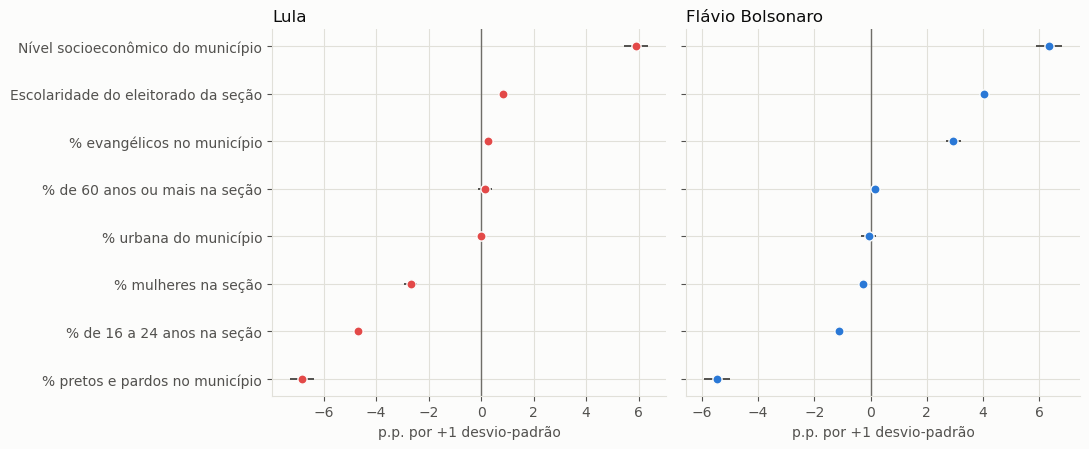

In [7]:
fig, eixos = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
for ax, n in zip(eixos, ('13', '22')):
    ef = C[n]['efeitos']
    chaves = sorted(ef, key=lambda k: ef[k]['pp'])
    y = np.arange(len(chaves))
    boot = C[n].get('bootstrap', {}).get('efeitos_pp', {})
    for yi, k in zip(y, chaves):
        lo, hi = boot.get(k, ef[k]['pp_ic'])
        ax.hlines(yi, lo, hi, color=TINTA2, lw=1.4)
    ax.scatter([ef[k]['pp'] for k in chaves], y, s=44, color=COR[n], edgecolor='#fcfcfb', zorder=3)
    ax.axvline(0, color=TINTA3, lw=1)
    ax.set_yticks(y, [ef[k]['rotulo'] for k in chaves])
    ax.set_title(NOME[n], loc='left', color=TINTA)
    ax.set_xlabel('p.p. por +1 desvio-padrão')
fig.tight_layout()

## 5. Dentro e entre cidades, escolaridade por estado, 4 níveis e robustez

A escolaridade da seção é um índice (% superior completo − % até o fundamental incompleto; r = −0,67 entre os dois).

In [8]:
# dentro da cidade x entre cidades (Mundlak simples: perfil + região), p.p. por +1 desvio-padrão
pd.concat({NOME[n]: pd.DataFrame(C[n]['mundlak_simples']).T for n in ('13', '22')}, axis=1)

Lula          Flávio Bolsonaro         
        pp_dentro pp_entre        pp_dentro pp_entre
mulher      0.249    0.282           -0.244   -0.276
16_24       0.804    8.011           -1.067   -7.523
60_mais    -0.012    3.631            0.129   -3.304
escol      -3.378   -2.560            2.902    1.986

In [9]:
for n in ('13', '22'):
    i, it = C[n]['inclinacao_escolaridade'], C[n]['interacoes']
    print(f"{NOME[n]}: inclinação da escolaridade por estado, variância {i['variancia']:.4f}, LR = {i['LR']:,.0f}, p = {i['p']:.1e}")
    print('   por região (p.p./DP):', {k: round(v, 2) for k, v in it['escolaridade_por_regiao_pp'].items()},
          f"| escolaridade × socioeconômico: {it['escolaridade_x_socio_pp']:+.2f} p.p.")
    print('   4 níveis:', {k: f'{v:.0%}' for k, v in C[n]['quatro_niveis']['icc'].items()})
    print('   robustez:', json.dumps(C[n]['robustez'], ensure_ascii=False)[:300])

Lula: inclinação da escolaridade por estado, variância 0.0338, LR = 48,693, p = 0.0e+00
   por região (p.p./DP): {'SE': -8.15, 'N': -6.12, 'NE': -7.39, 'CO': -8.54, 'S': -8.47} | escolaridade × socioeconômico: +3.76 p.p.
   4 níveis: {'secao': '3%', 'uf': '56%', 'mun': '21%', 'local': '20%'}
   robustez: {"escala_proporcao": {"queda": {"uf": 0.9211612960131156, "mun": 0.3981713487770946, "secao": 0.24004730047846046}}, "secoes_100_validos": {"n": 492185, "queda": {"uf": 0.9080164143415179, "mun": 0.37034981675751744, "secao": 0.22696803146964772}}}
Flávio Bolsonaro: inclinação da escolaridade por estado, variância 0.0332, LR = 53,507, p = 0.0e+00
   por região (p.p./DP): {'SE': 7.54, 'N': 5.51, 'NE': 7.18, 'CO': 8.63, 'S': 8.04} | escolaridade × socioeconômico: -4.05 p.p.
   4 níveis: {'secao': '3%', 'uf': '55%', 'mun': '21%', 'local': '21%'}
   robustez: {"escala_proporcao": {"queda": {"uf": 0.9125266503334405, "mun": 0.34767583012671777, "secao": 0.19712312088105854}}, "secoes_100_va

## 6. Espaço

Moran global e LISA nos efeitos dos municípios (contiguidade da malha do IBGE), o modelo com processo gaussiano nas
coordenadas (degrau x rampa), as regiões de voto do SKATER e São Paulo por local de votação.

In [10]:
tab = {}
for n in ('13', '22'):
    e = espacial['candidatos'][n]
    tab[NOME[n]] = {'Moran (nulo)': e['nulo']['moran_I'], 'Moran (completo)': e['completo']['moran_I'],
                    'queda da var. do estado com o GP': e['degrau_gradiente']['queda_uf'],
                    'alcance do GP (km)': e['degrau_gradiente']['com_gp']['alcance_km'],
                    'R² 27 regiões de voto': espacial['regioes'][n]['r2_regioes'],
                    'R² 27 estados': espacial['regioes'][n]['r2_estados'],
                    'Moran dos locais em SP': espacial['sao_paulo'][n]['moran_I']}
pd.DataFrame(tab)

,Lula,Flávio Bolsonaro
Moran (nulo),0.560,0.559
Moran (completo),0.466,0.473
queda da var. do estado com o GP,0.936,0.928
alcance do GP (km),342.355,363.254
R² 27 regiões de voto,0.844,0.838
R² 27 estados,0.744,0.731
Moran dos locais em SP,0.706,0.684


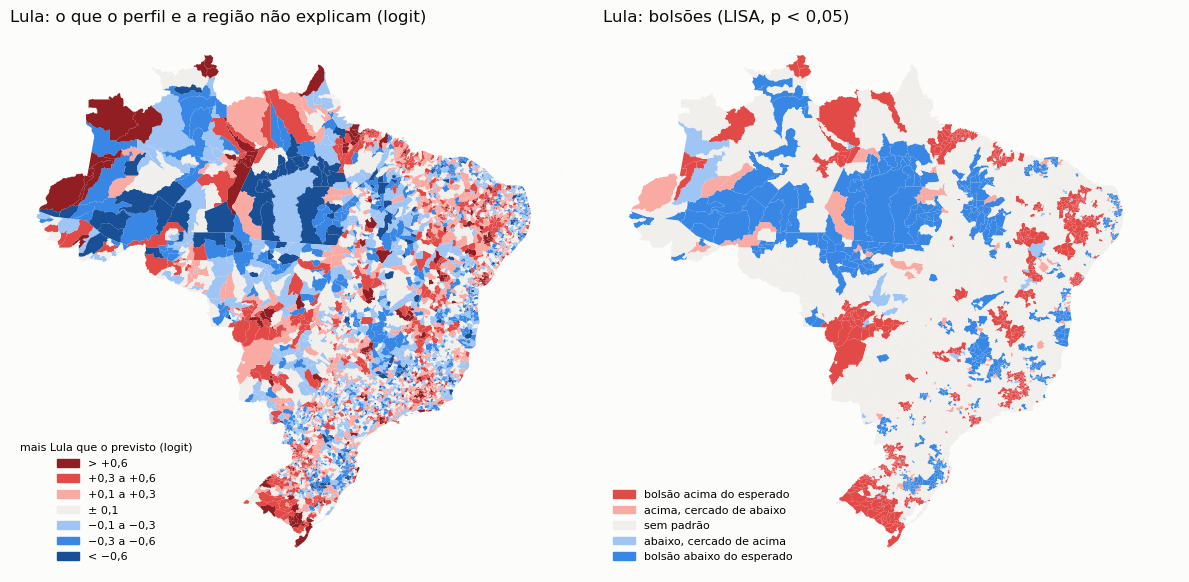

In [11]:
malha = gpd.read_file(RAIZ / 'data/geo/municipios_br_minima.topo.json')
malha['CD_MUNICIPIO_IBGE'] = malha.codarea.astype(int)
ctx = pd.read_parquet(RAIZ / 'data/processed/contexto_municipal.parquet', columns=['CD_MUNICIPIO', 'CD_MUNICIPIO_IBGE'])
ef = pd.read_parquet(RAIZ / 'data/processed/efeitos_stepup.parquet')
esp = pd.read_parquet(RAIZ / 'data/processed/espacial_municipios.parquet')
g = malha.merge(ctx, on='CD_MUNICIPIO_IBGE').merge(ef, on='CD_MUNICIPIO').merge(esp, on='CD_MUNICIPIO')
DIVERGENTE = ['#911e22', '#e24a48', '#f8aaa3', '#f0efec', '#9ec5f4', '#3987e5', '#184f95']
from matplotlib.colors import BoundaryNorm, ListedColormap
fig, eixos = plt.subplots(1, 2, figsize=(12, 6))
v = -g['u_mun_completo_13']  # positivo (vermelho) = mais Lula do que o modelo completo prevê
g.assign(v=v).plot(column='v', ax=eixos[0], cmap=ListedColormap(DIVERGENTE),
                   norm=BoundaryNorm([-9, -0.6, -0.3, -0.1, 0.1, 0.3, 0.6, 9], 7), linewidth=0)
eixos[0].set_title('Lula: o que o perfil e a região não explicam (logit)', loc='left', color=TINTA)
cores_lisa = {0: '#f0efec', 1: '#e24a48', 2: '#9ec5f4', 3: '#3987e5', 4: '#f8aaa3'}
g.plot(color=g['lisa_completo_13'].map(cores_lisa), ax=eixos[1], linewidth=0)
eixos[1].set_title('Lula: bolsões (LISA, p < 0,05)', loc='left', color=TINTA)
from matplotlib.patches import Patch
faixas = ['> +0,6', '+0,3 a +0,6', '+0,1 a +0,3', '± 0,1', '−0,1 a −0,3', '−0,3 a −0,6', '< −0,6']
eixos[0].legend(handles=[Patch(color=c, label=f) for c, f in zip(DIVERGENTE, faixas)], title='mais Lula que o previsto (logit)',
                loc='lower left', frameon=False, fontsize=8, title_fontsize=8)
rotulos_lisa = {1: 'bolsão acima do esperado', 4: 'acima, cercado de abaixo', 0: 'sem padrão', 2: 'abaixo, cercado de acima', 3: 'bolsão abaixo do esperado'}
eixos[1].legend(handles=[Patch(color=cores_lisa[k], label=r) for k, r in rotulos_lisa.items()], loc='lower left', frameon=False, fontsize=8)
for ax in eixos:
    ax.set_axis_off()
fig.tight_layout()

## Leitura

- O perfil de quem vota em cada urna (idade, sexo, escolaridade) explica pouco da diferença entre estados; o perfil dos
  municípios (renda e economia, cor ou raça, religião) explica bem mais; e grande parte do resto é regional.
- A região é um rótulo, não uma explicação: o que ela captura (história política, redes, lideranças) não está medido aqui.
- O que nem perfil nem região explicam forma bolsões de municípios vizinhos, e o mesmo acontece entre locais de votação
  dentro de São Paulo.
- Limitações: agregados (seções e municípios), Censo de 2022 para 2026, eleitor vota onde está registrado, logit sem peso
  (a versão binomial está na robustez).